In [10]:
import torch
import torch.nn as nn
import numpy as np
from math import e, pi
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch.nn.functional as F


In [11]:
class FCN(nn.Module):

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()

        activation = nn.Tanh

        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )

        self.fch = nn.Sequential(*[
            nn.Sequential(
                nn.Linear(N_HIDDEN, N_HIDDEN),
                activation()
            ) for _ in range(N_LAYERS-1)
        ])

        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x, t):

        inp = torch.cat([x, t], dim=1)   # combine space and time

        x = self.fcs(inp)
        x = self.fch(x)
        x = self.fce(x)

        return F.softplus(x)

In [12]:
def loss_pde(model, x, t, D):
    x.requires_grad_(True)
    t.requires_grad_(True)
    C = model(x, t)
    C_t = torch.autograd.grad(C, t, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    C_x = torch.autograd.grad(C, x, grad_outputs=torch.ones_like(C),create_graph=True)[0]
    C_xx = torch.autograd.grad(C_x, x, grad_outputs=torch.ones_like(C_x),create_graph=True)[0]
    residual = C_t - D * C_xx
    return torch.mean(residual**2)

def loss_ic(model, x, Q, sigma):
    t = torch.zeros_like(x)
    C_pred = model(x, t)
    C_true = Q/(np.sqrt(2*np.pi)*sigma) * torch.exp(-(x**2)/(2*sigma**2))
    return torch.mean((C_pred - C_true)**2)

def loss_bc(model, t, L):
    x_left  = -L * torch.ones_like(t)
    x_right =  L * torch.ones_like(t)
    C_left  = model(x_left, t)
    C_right = model(x_right, t)
    return torch.mean(C_left**2 + C_right**2)

def loss_mass(model, x, t, Q):
    C = model(x, t)
    integral = torch.trapz(C.squeeze(), x.squeeze())
    return (integral - Q)**2



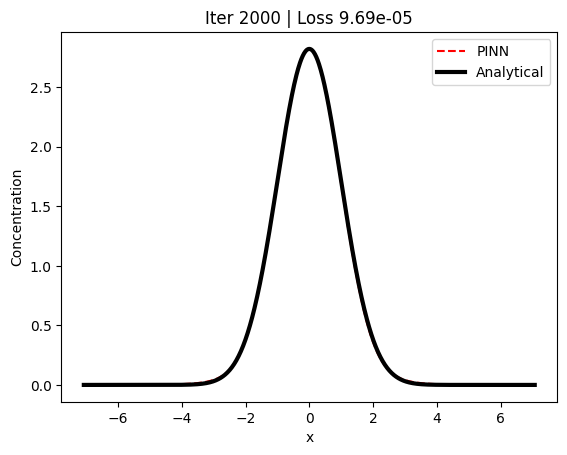

In [14]:
torch.manual_seed(123)

pinn = FCN(
    N_INPUT=2,
    N_OUTPUT=1,
    N_HIDDEN=64,
    N_LAYERS=4
)

L = 1.0
T = 1.0

x_pde = -L + 2*L*torch.rand(1000,1)
t_pde = 1e-4 + (T-1e-4)*torch.rand(1000,1)
x_ic = torch.linspace(-L,L,200).view(-1,1)
t_bc = torch.rand(200,1)*T
x_mass = torch.linspace(-L,L,500).view(-1,1)
t_mass = torch.ones_like(x_mass)*0.5

# train the PINN
D = 0.02
Q = 1

sigma = 0.02

frames = []
x_test = -L + 2*L*torch.rand(1000,1)
t_test = 1e-4 + (T-1e-4)*torch.rand(1000,1)
optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-3)
losses = []
x_plot = torch.linspace(-1,1,1000).view(-1,1)
t_plot = torch.ones_like(x_plot)*0.5
C_true =  Q/torch.sqrt(4*np.pi*D*t_plot) * torch.exp(-x_plot**2/(4*D*t_plot))
best_loss = float("inf")
for i in range(2001):
    optimiser.zero_grad()

    l_pde  = loss_pde(pinn, x_pde, t_pde, D)
    l_ic   = loss_ic(pinn, x_ic, Q, sigma)
    l_bc   = loss_bc(pinn, t_bc, L)
    l_mass = loss_mass(pinn, x_mass, t_mass, Q)

    loss = l_pde + l_ic + l_bc + l_mass
    loss.backward()
    optimiser.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({
            "iteration": i,
            "model_state_dict": pinn.state_dict(),
            "optimizer_state_dict": optimiser.state_dict(),
            "loss": best_loss
        },
        "experiments/checkpoints/best_model.pt")
    if i % 10 == 0:
        with torch.no_grad():
            C_pred = pinn(x_plot,t_plot)
        frames.append(C_pred)
        losses.append(torch.mean((C_pred - C_true)**2))

import numpy as np

np.save("frames.npy", np.array(frames))
np.save("losses.npy", np.array(losses))

fig, ax = plt.subplots()

line_pinn, = ax.plot([],[], '--', color="red", label="PINN")

line_true, = ax.plot((x_plot/torch.sqrt(2*D*t_plot)).numpy(),C_true,
                     color="black",linewidth=3,
                     label="Analytical")


ax.legend()
title = ax.set_title("")
ax.set_xlabel("x")
ax.set_ylabel("Concentration")

def update(i):
    line_pinn.set_data((x_plot/torch.sqrt(2*D*t_plot)).numpy(),frames[i])
    title.set_text(f"Iter {10*i} | Loss {losses[i].item():.2e}")
    return line_pinn, title

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=200,
    blit=True
)

ani.save("pinn_training.gif", writer="pillow", fps=5)


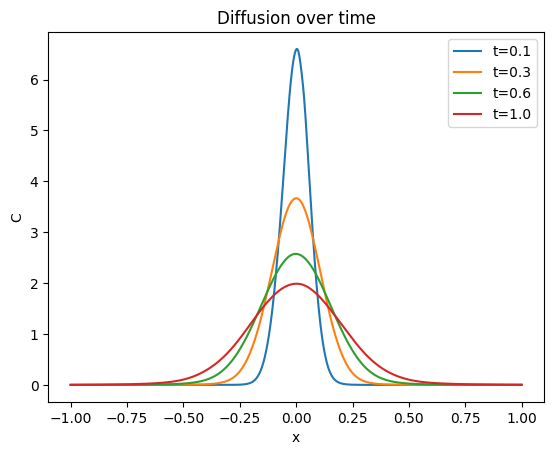

In [15]:
times = [0.1,0.3,0.6,1.0]

plt.figure()

for t_val in times:

    t_plot = torch.ones_like(x_plot)*t_val

    with torch.no_grad():
        C_pred = pinn(x_plot,t_plot)

    plt.plot(x_plot.numpy(),C_pred.numpy(),label=f"t={t_val}")

plt.legend()
plt.xlabel("x")
plt.ylabel("C")
plt.title("Diffusion over time")
plt.show()

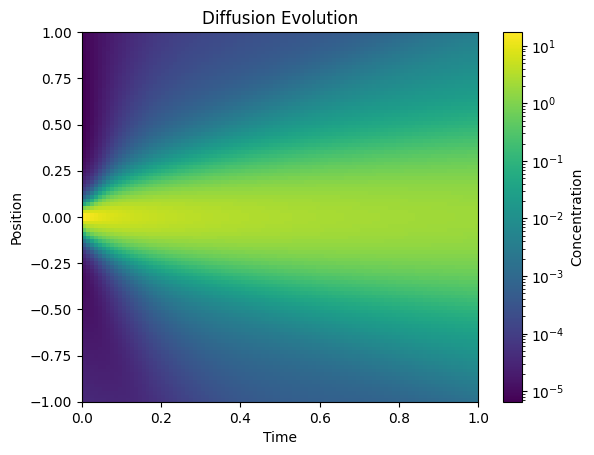

In [16]:
x = torch.linspace(-1,1,100)
t = torch.linspace(0.01,1,100)

X,T = torch.meshgrid(x,t,indexing='ij')

Xf = X.reshape(-1,1)
Tf = T.reshape(-1,1)

with torch.no_grad():
    C = pinn(Xf,Tf)

C = C.reshape(100,100)

plt.figure()

from matplotlib import colors
plt.imshow(C,
           extent=[0,1,-1,1],
           aspect="auto",
           origin="lower",
           norm=colors.LogNorm())

plt.colorbar(label="Concentration")

plt.xlabel("Time")
plt.ylabel("Position")

plt.title("Diffusion Evolution")

plt.show()

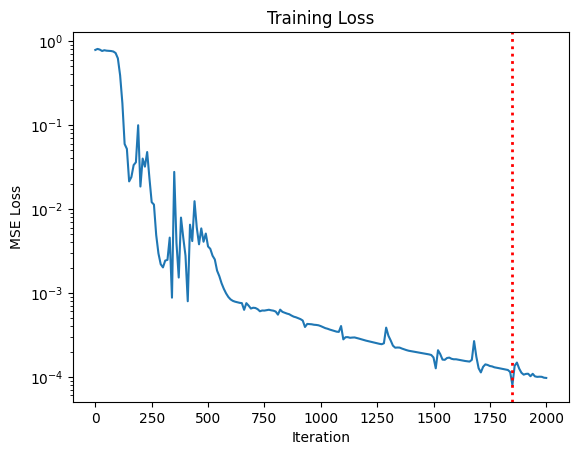

tensor(8.0003e-05)

In [17]:
plt.plot(range(0, 2001, 10), losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.yscale("log")
min_idx = np.argmin(losses)
min_loss = losses[min_idx]
plt.axvline(min_idx*10,
            color="red",
            linestyle=":",
            linewidth=2,
            label=f"Min loss = {min_loss:.2e}")
plt.title("Training Loss")
plt.show()
min(losses)